# **Dataset**

In [6]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, matthews_corrcoef, roc_auc_score

from xgboost import XGBClassifier

In [7]:
import pandas as pd
import numpy as np

df201 = pd.read_csv("/content/model_input_20k_201bp_rich.tsv", sep="\t")

df201["label_num"] = (df201["label"] == "somatic").astype(int)
df201["mutation_type"] = df201["ref"] + ">" + df201["alt"]

print(df201.shape)
print(df201["label"].value_counts())

(20000, 14)
label
somatic     10000
germline    10000
Name: count, dtype: int64


In [8]:
seq_label_counts = df201.groupby("mut_seq")["label_num"].nunique()
ambiguous_seqs = seq_label_counts[seq_label_counts > 1].index

df201_clean = df201[~df201["mut_seq"].isin(ambiguous_seqs)].copy()

seq_df = (
    df201_clean
    .groupby("mut_seq", as_index=False)
    .agg({
        "label": "first",
        "label_num": "first",
        "ref": "first",
        "alt": "first",
        "mutation_type": "first"
    })
)

print(seq_df.shape)
print(seq_df["label"].value_counts())
print("Ambiguous removed:", len(ambiguous_seqs))

(20000, 6)
label
somatic     10000
germline    10000
Name: count, dtype: int64
Ambiguous removed: 0


In [9]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    seq_df,
    test_size=0.40,
    random_state=42,
    stratify=seq_df["label_num"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label_num"]
)

print(train_df.shape, val_df.shape, test_df.shape)

(12000, 6) (4000, 6) (4000, 6)


In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import hstack

vectorizers = {}

X_train_parts = []
X_val_parts = []
X_test_parts = []

for k in [3, 4, 5, 6]:
    vec = CountVectorizer(
        analyzer="char",
        ngram_range=(k, k)
    )

    X_train_k = vec.fit_transform(train_df["mut_seq"])
    X_val_k   = vec.transform(val_df["mut_seq"])
    X_test_k  = vec.transform(test_df["mut_seq"])

    vectorizers[k] = vec

    X_train_parts.append(X_train_k)
    X_val_parts.append(X_val_k)
    X_test_parts.append(X_test_k)

X_train = hstack(X_train_parts)
X_val   = hstack(X_val_parts)
X_test  = hstack(X_test_parts)

y_train = train_df["label_num"]
y_val   = val_df["label_num"]
y_test  = test_df["label_num"]

print(X_train.shape, X_val.shape, X_test.shape)

(12000, 5440) (4000, 5440) (4000, 5440)


# **Models**

# **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg201 = LogisticRegression(
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)

logreg201.fit(X_train, y_train)

LogisticRegression(max_iter=5000, n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import roc_auc_score

test_prob = logreg201.predict_proba(X_test)[:,1]
test_pred = logreg201.predict(X_test)

print("201bp clean sequence-level Logistic Regression")
print(classification_report(y_test, test_pred))

print("MCC:", matthews_corrcoef(y_test, test_pred))
print("ROC-AUC:", roc_auc_score(y_test, test_prob))

201bp clean sequence-level Logistic Regression
              precision    recall  f1-score   support

           0       0.59      0.58      0.58      2000
           1       0.59      0.59      0.59      2000

    accuracy                           0.59      4000
   macro avg       0.59      0.59      0.59      4000
weighted avg       0.59      0.59      0.59      4000

MCC: 0.17250485176718489
ROC-AUC: 0.61212775


In [ ]:
val_prob = logreg201.predict_proba(X_val)[:,1]

best_t = 0.5
best_mcc = -999

for t in np.arange(0.1, 0.9, 0.01):
    pred = (val_prob >= t).astype(int)
    mcc = matthews_corrcoef(y_val, pred)

    if mcc > best_mcc:
        best_mcc = mcc
        best_t = t

print("Best threshold:", best_t)
print("Validation MCC:", best_mcc)

Best threshold: 0.8499999999999996
Validation MCC: 0.15552315827194782


In [ ]:
test_prob = logreg201.predict_proba(X_test)[:,1]
test_pred = (test_prob >= best_t).astype(int)

print(classification_report(y_test, test_pred))
print("MCC:", matthews_corrcoef(y_test, test_pred))
print("ROC-AUC:", roc_auc_score(y_test, test_prob))

              precision    recall  f1-score   support

           0       0.54      0.83      0.65      2000
           1       0.63      0.28      0.39      2000

    accuracy                           0.56      4000
   macro avg       0.58      0.56      0.52      4000
weighted avg       0.58      0.56      0.52      4000

MCC: 0.13987212282278133
ROC-AUC: 0.61212775


# **XGBoost**

In [ ]:
from xgboost import XGBClassifier

xgb201 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb201.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import classification_report, matthews_corrcoef, roc_auc_score

val_prob = xgb201.predict_proba(X_val)[:, 1]
test_prob = xgb201.predict_proba(X_test)[:, 1]

test_pred = (test_prob >= 0.5).astype(int)

print("201bp clean sequence-level XGBoost")
print(classification_report(y_test, test_pred))
print("MCC:", matthews_corrcoef(y_test, test_pred))
print("ROC-AUC:", roc_auc_score(y_test, test_prob))

201bp clean sequence-level XGBoost
              precision    recall  f1-score   support

           0       0.63      0.65      0.64      2000
           1       0.64      0.62      0.63      2000

    accuracy                           0.63      4000
   macro avg       0.63      0.63      0.63      4000
weighted avg       0.63      0.63      0.63      4000

MCC: 0.2670834766317097
ROC-AUC: 0.6809015


# **XGBoost only with mutation sequence window**

In [ ]:
for d in [train_df, val_df, test_df]:
    d["center_3"] = d["mut_seq"].str[99:102]
    d["center_5"] = d["mut_seq"].str[98:103]
    d["center_7"] = d["mut_seq"].str[97:104]

In [ ]:
from scipy.sparse import hstack
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, matthews_corrcoef, roc_auc_score


center_encoder = OneHotEncoder(handle_unknown="ignore")

X_train_center = center_encoder.fit_transform(
    train_df[["center_3", "center_5", "center_7"]]
)

X_val_center = center_encoder.transform(
    val_df[["center_3", "center_5", "center_7"]]
)

X_test_center = center_encoder.transform(
    test_df[["center_3", "center_5", "center_7"]]
)


X_train_plus_center = hstack([X_train, X_train_center])
X_val_plus_center   = hstack([X_val, X_val_center])
X_test_plus_center  = hstack([X_test, X_test_center])

print(X_train_plus_center.shape, X_val_plus_center.shape, X_test_plus_center.shape)

(12000, 13986) (4000, 13986) (4000, 13986)


In [ ]:
xgb_center = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_center.fit(X_train_plus_center, y_train)

pred = xgb_center.predict(X_test_plus_center)
proba = xgb_center.predict_proba(X_test_plus_center)[:, 1]

print("201bp clean k-mers + centered motifs XGBoost")
print(classification_report(y_test, pred))
print("MCC:", matthews_corrcoef(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))

201bp clean k-mers + centered motifs XGBoost
              precision    recall  f1-score   support

           0       0.63      0.66      0.65      2000
           1       0.64      0.62      0.63      2000

    accuracy                           0.64      4000
   macro avg       0.64      0.64      0.64      4000
weighted avg       0.64      0.64      0.64      4000

MCC: 0.27718980140083593
ROC-AUC: 0.685646


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, matthews_corrcoef, roc_auc_score


for d in [train_df, val_df, test_df]:
    d["center_11"] = d["mut_seq"].str[95:106]
    d["center_21"] = d["mut_seq"].str[90:111]
    d["center_31"] = d["mut_seq"].str[85:116]


center_encoder_wide = OneHotEncoder(handle_unknown="ignore")

X_train_center_wide = center_encoder_wide.fit_transform(
    train_df[["center_11", "center_21", "center_31"]]
)

X_val_center_wide = center_encoder_wide.transform(
    val_df[["center_11", "center_21", "center_31"]]
)

X_test_center_wide = center_encoder_wide.transform(
    test_df[["center_11", "center_21", "center_31"]]
)


X_train_wide = hstack([X_train, X_train_center_wide])
X_val_wide   = hstack([X_val, X_val_center_wide])
X_test_wide  = hstack([X_test, X_test_center_wide])

print(X_train_wide.shape, X_val_wide.shape, X_test_wide.shape)


xgb_wide_center = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_wide_center.fit(X_train_wide, y_train)


pred = xgb_wide_center.predict(X_test_wide)
proba = xgb_wide_center.predict_proba(X_test_wide)[:, 1]

print("201bp clean k-mers + wide centered motifs XGBoost")
print(classification_report(y_test, pred))
print("MCC:", matthews_corrcoef(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))

(12000, 41381) (4000, 41381) (4000, 41381)
201bp clean k-mers + wide centered motifs XGBoost
              precision    recall  f1-score   support

           0       0.62      0.65      0.64      2000
           1       0.63      0.61      0.62      2000

    accuracy                           0.63      4000
   macro avg       0.63      0.63      0.63      4000
weighted avg       0.63      0.63      0.63      4000

MCC: 0.25916799530908735
ROC-AUC: 0.68265625


# **CNN 1D**

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, matthews_corrcoef, roc_auc_score

base_to_vec = {
    "A": [1,0,0,0],
    "C": [0,1,0,0],
    "G": [0,0,1,0],
    "T": [0,0,0,1]
}

def one_hot(seq):
    return np.array(
        [base_to_vec.get(b, [0,0,0,0]) for b in seq],
        dtype=np.float32
    )

X_train_cnn = np.stack(train_df["mut_seq"].apply(one_hot).values)
X_val_cnn   = np.stack(val_df["mut_seq"].apply(one_hot).values)
X_test_cnn  = np.stack(test_df["mut_seq"].apply(one_hot).values)

y_train_cnn = train_df["label_num"].values
y_val_cnn   = val_df["label_num"].values
y_test_cnn  = test_df["label_num"].values

print(X_train_cnn.shape)
print(X_val_cnn.shape)
print(X_test_cnn.shape)

(12000, 201, 4)
(4000, 201, 4)
(4000, 201, 4)


In [ ]:
from tensorflow.keras import layers, models

cnn_201 = models.Sequential([
    layers.Input(shape=(201, 4)),

    layers.Conv1D(32, kernel_size=7, activation="relu", padding="same"),
    layers.GlobalMaxPooling1D(),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

cnn_201.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

cnn_201.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 201, 32)        │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,017 (7.88 KB)

 Trainable params: 2,017 (7.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    patience=5,
    mode="max",
    restore_best_weights=True
)

history_cnn = cnn_201.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=40,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.5086 - auc: 0.5071 - loss: 0.7028 - val_accuracy: 0.5580 - val_auc: 0.5861 - val_loss: 0.6883
Epoch 2/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.5552 - auc: 0.5757 - loss: 0.6849 - val_accuracy: 0.5863 - val_auc: 0.6219 - val_loss: 0.6803
Epoch 3/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.5848 - auc: 0.6178 - loss: 0.6754 - val_accuracy: 0.5993 - val_auc: 0.6298 - val_loss: 0.6728
Epoch 4/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.5985 - auc: 0.6294 - loss: 0.6696 - val_accuracy: 0.5945 - val_auc: 0.6342 - val_loss: 0.6684
Epoch 5/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.5987 - auc: 0.6352 - loss: 0.6650 - val_accuracy: 0.6068 - val_auc: 0.6374 - val_loss: 0.6657
Epoch 6/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.6115 - auc: 0.6420 - loss: 0.6624 - val_accuracy: 0.6070 - val_auc: 0.6402 - val_loss: 0.6637
Epoch 7/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/

In [ ]:
val_prob = cnn_201.predict(X_val_cnn).ravel()
test_prob = cnn_201.predict(X_test_cnn).ravel()

best_t = 0.5
best_mcc = -999

for t in np.arange(0.1, 0.9, 0.01):
    val_pred = (val_prob >= t).astype(int)
    mcc = matthews_corrcoef(y_val_cnn, val_pred)

    if mcc > best_mcc:
        best_t = t
        best_mcc = mcc

test_pred = (test_prob >= best_t).astype(int)

print("Best threshold:", best_t)
print("Validation MCC:", best_mcc)

print("201bp clean MUT-only CNN")
print(classification_report(y_test_cnn, test_pred))
print("MCC:", matthews_corrcoef(y_test_cnn, test_pred))
print("ROC-AUC:", roc_auc_score(y_test_cnn, test_prob))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Best threshold: 0.5499999999999998
Validation MCC: 0.2438618676952169
201bp clean MUT-only CNN
              precision    recall  f1-score   support

           0       0.60      0.65      0.62      2000
           1       0.62      0.57      0.59      2000

    accuracy                           0.61      4000
   macro avg       0.61      0.61      0.61      4000
weighted avg       0.61      0.61      0.61      4000

MCC: 0.2206213726481161
ROC-AUC: 0.6502915


# **Nucleotide Transformer embeddings + XGBoost**

In [ ]:
!pip -q install transformers accelerate einops xgboost

In [ ]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, matthews_corrcoef, roc_auc_score
from xgboost import XGBClassifier

In [ ]:
from transformers import AutoTokenizer, AutoConfig, AutoModelForSequenceClassification
import torch

MODEL_NAME = "InstaDeepAI/nucleotide-transformer-500m-human-ref"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

config = AutoConfig.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

config.num_labels = 2
config.pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0

bert_cls = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config,
    trust_remote_code=True,
    ignore_mismatched_sizes=True,
    low_cpu_mem_usage=False
)

device = "cuda" if torch.cuda.is_available() else "cpu"
bert_cls = bert_cls.to(device)
bert_cls.eval()

print(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/706 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/28.7k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/101 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] EsmForSequenceClassification LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                        | Status     | 
---------------------------+------------+-
lm_head.decoder.weight     | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


cpu


In [ ]:
def get_nt_embedding(seq):
    inputs = tokenizer(
        seq,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = bert_cls.base_model(**inputs)

    hidden = outputs[0]
    emb = hidden.mean(dim=1).cpu().numpy()[0]

    return emb

In [ ]:
def get_nt_embedding(seq):
    inputs = tokenizer(
        seq,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = bert_cls.base_model(**inputs)

    hidden = outputs[0]
    emb = hidden.mean(dim=1).cpu().numpy()[0]

    return emb

In [ ]:
def embed_split(df_split, name):
    embeddings = []
    labels = []

    for _, row in tqdm(df_split.iterrows(), total=len(df_split), desc=name):
        embeddings.append(get_nt_embedding(row["mut_seq"]))
        labels.append(row["label_num"])

    X = np.vstack(embeddings)
    y = np.array(labels)

    np.save(f"nt_embeddings_{name}.npy", X)
    np.save(f"nt_labels_{name}.npy", y)

    print(name, X.shape, y.shape)

    return X, y

In [ ]:
X_train_nt, y_train_nt = embed_split(train_df, "train_201_clean")
X_val_nt, y_val_nt     = embed_split(val_df, "val_201_clean")
X_test_nt, y_test_nt   = embed_split(test_df, "test_201_clean")

train_201_clean: 100%|██████████| 12000/12000 [3:21:14<00:00,  1.01s/it]


train_201_clean (12000, 1280) (12000,)


val_201_clean: 100%|██████████| 4000/4000 [1:04:26<00:00,  1.03it/s]


val_201_clean (4000, 1280) (4000,)


test_201_clean: 100%|██████████| 4000/4000 [1:06:13<00:00,  1.01it/s]

test_201_clean (4000, 1280) (4000,)


In [ ]:
nt_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

nt_xgb.fit(X_train_nt, y_train_nt)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
test_prob = nt_xgb.predict_proba(X_test_nt)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

print("Clean 201bp Nucleotide Transformer embeddings + XGBoost")
print(classification_report(y_test_nt, test_pred))
print("MCC:", matthews_corrcoef(y_test_nt, test_pred))
print("ROC-AUC:", roc_auc_score(y_test_nt, test_prob))

Clean 201bp Nucleotide Transformer embeddings + XGBoost
              precision    recall  f1-score   support

           0       0.63      0.66      0.64      2000
           1       0.64      0.61      0.63      2000

    accuracy                           0.64      4000
   macro avg       0.64      0.64      0.63      4000
weighted avg       0.64      0.64      0.63      4000

MCC: 0.270298709978959
ROC-AUC: 0.69175


In [ ]:
val_prob = nt_xgb.predict_proba(X_val_nt)[:, 1]

best_t = 0.5
best_mcc = -999

for t in np.arange(0.1, 0.9, 0.01):
    val_pred = (val_prob >= t).astype(int)
    mcc = matthews_corrcoef(y_val_nt, val_pred)

    if mcc > best_mcc:
        best_mcc = mcc
        best_t = t

test_pred = (test_prob >= best_t).astype(int)

print("Best threshold:", best_t)
print("Validation MCC:", best_mcc)

print("Clean 201bp NT embeddings + XGBoost, threshold tuned")
print(classification_report(y_test_nt, test_pred))
print("MCC:", matthews_corrcoef(y_test_nt, test_pred))
print("ROC-AUC:", roc_auc_score(y_test_nt, test_prob))

Best threshold: 0.6099999999999998
Validation MCC: 0.30412460194301066
Clean 201bp NT embeddings + XGBoost, threshold tuned
              precision    recall  f1-score   support

           0       0.59      0.84      0.69      2000
           1       0.72      0.41      0.52      2000

    accuracy                           0.62      4000
   macro avg       0.65      0.62      0.60      4000
weighted avg       0.65      0.62      0.60      4000

MCC: 0.27213887540816273
ROC-AUC: 0.69175


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/dna_mutation_project"

import os
os.makedirs(SAVE_DIR, exist_ok=True)

np.save(f"{SAVE_DIR}/X_train_nt_201_clean.npy", X_train_nt)
np.save(f"{SAVE_DIR}/X_val_nt_201_clean.npy", X_val_nt)
np.save(f"{SAVE_DIR}/X_test_nt_201_clean.npy", X_test_nt)

np.save(f"{SAVE_DIR}/y_train_nt_201_clean.npy", y_train_nt)
np.save(f"{SAVE_DIR}/y_val_nt_201_clean.npy", y_val_nt)
np.save(f"{SAVE_DIR}/y_test_nt_201_clean.npy", y_test_nt)

print("Saved clean NT embeddings and labels.")

Saved clean NT embeddings and labels.


# **Hybrid Model**

In [ ]:
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, matthews_corrcoef, roc_auc_score
import numpy as np

In [ ]:
preprocess_bio = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

X_train_bio = preprocess_bio.fit_transform(train_deft[all_features])
X_val_bio   = preprocess_bio.transform(val_deft[all_features])
X_test_bio  = preprocess_bio.transform(test_deft[all_features])

X_train_hybrid = hstack([csr_matrix(X_train_nt), X_train_bio])
X_val_hybrid   = hstack([csr_matrix(X_val_nt), X_val_bio])
X_test_hybrid  = hstack([csr_matrix(X_test_nt), X_test_bio])

print(X_train_hybrid.shape, X_val_hybrid.shape, X_test_hybrid.shape)

(12000, 9853) (4000, 9853) (4000, 9853)


In [ ]:
hybrid_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

hybrid_xgb.fit(X_train_hybrid, y_train_nt)

test_prob = hybrid_xgb.predict_proba(X_test_hybrid)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

print("Hybrid DEFT-inspired: NT embeddings + biological features + XGBoost")
print(classification_report(y_test_nt, test_pred))
print("MCC:", matthews_corrcoef(y_test_nt, test_pred))
print("ROC-AUC:", roc_auc_score(y_test_nt, test_prob))

Hybrid DEFT-inspired: NT embeddings + biological features + XGBoost
              precision    recall  f1-score   support

           0       0.65      0.69      0.67      2000
           1       0.67      0.62      0.64      2000

    accuracy                           0.66      4000
   macro avg       0.66      0.66      0.66      4000
weighted avg       0.66      0.66      0.66      4000

MCC: 0.31288121939187374
ROC-AUC: 0.72204625


In [ ]:
val_prob = hybrid_xgb.predict_proba(X_val_hybrid)[:, 1]

best_t = 0.5
best_mcc = -999

for t in np.arange(0.1, 0.9, 0.01):
    val_pred = (val_prob >= t).astype(int)
    mcc = matthews_corrcoef(y_val_nt, val_pred)

    if mcc > best_mcc:
        best_mcc = mcc
        best_t = t

test_pred = (test_prob >= best_t).astype(int)

print("Best threshold:", best_t)
print("Validation MCC:", best_mcc)

print("Hybrid DEFT-inspired tuned")
print(classification_report(y_test_nt, test_pred))
print("MCC:", matthews_corrcoef(y_test_nt, test_pred))
print("ROC-AUC:", roc_auc_score(y_test_nt, test_prob))

Best threshold: 0.6299999999999997
Validation MCC: 0.3375082557664872
Hybrid DEFT-inspired tuned
              precision    recall  f1-score   support

           0       0.59      0.87      0.70      2000
           1       0.75      0.41      0.53      2000

    accuracy                           0.64      4000
   macro avg       0.67      0.64      0.62      4000
weighted avg       0.67      0.64      0.62      4000

MCC: 0.30917402732338173
ROC-AUC: 0.72204625


In [ ]:
import joblib

joblib.dump(
    hybrid_xgb,
    "/content/drive/MyDrive/dna_mutation_project/hybrid_nt_deft_xgb.pkl"
)

['/content/drive/MyDrive/dna_mutation_project/hybrid_nt_deft_xgb.pkl']

In [ ]:
joblib.dump(
    preprocess_bio,
    "/content/drive/MyDrive/dna_mutation_project/preprocess_bio.pkl"
)

['/content/drive/MyDrive/dna_mutation_project/preprocess_bio.pkl']

In [ ]:
print("bert_xgb" in globals())
print("hybrid_xgb" in globals())

print("X_test_nt" in globals())
print("y_test_nt" in globals())

print("test_prob" in globals())

False
True
True
True
True


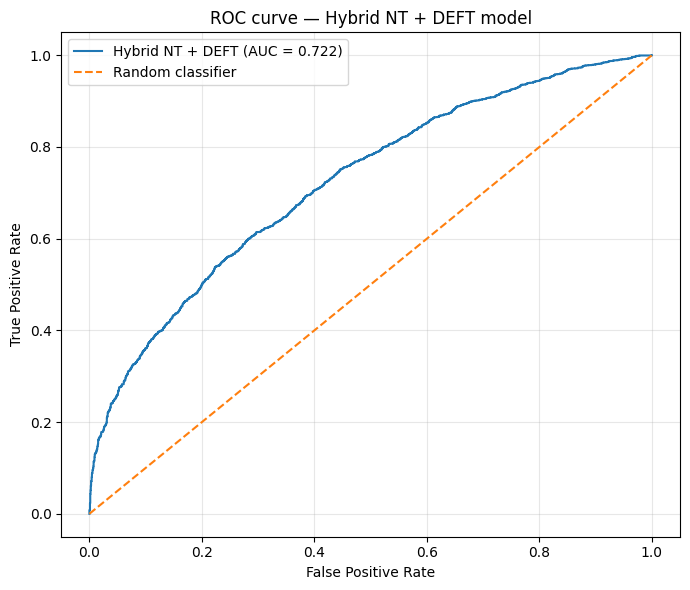

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

hybrid_prob = test_prob

fpr_hybrid, tpr_hybrid, _ = roc_curve(y_test_nt, hybrid_prob)
auc_hybrid = auc(fpr_hybrid, tpr_hybrid)

plt.figure(figsize=(7, 6))
plt.plot(fpr_hybrid, tpr_hybrid, label=f"Hybrid NT + DEFT (AUC = {auc_hybrid:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve — Hybrid NT + DEFT model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2157/3602056518.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


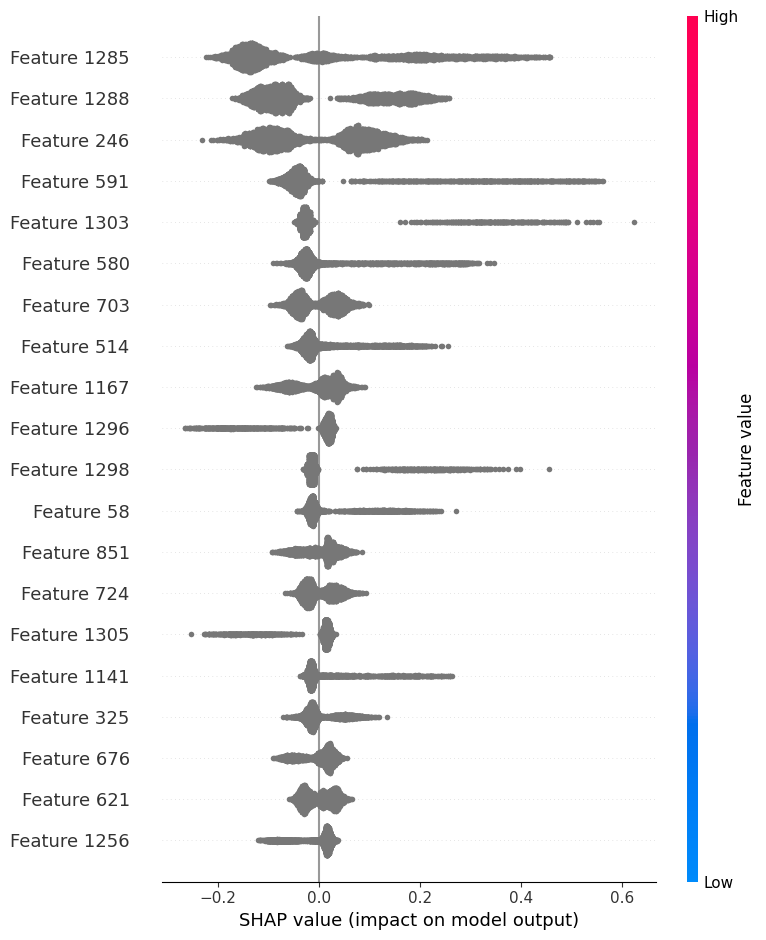

In [ ]:
import shap

explainer = shap.TreeExplainer(hybrid_xgb)

shap_values = explainer.shap_values(X_test_hybrid)

shap.summary_plot(
    shap_values,
    X_test_hybrid,
    max_display=20
)

/tmp/ipykernel_2157/1045720693.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


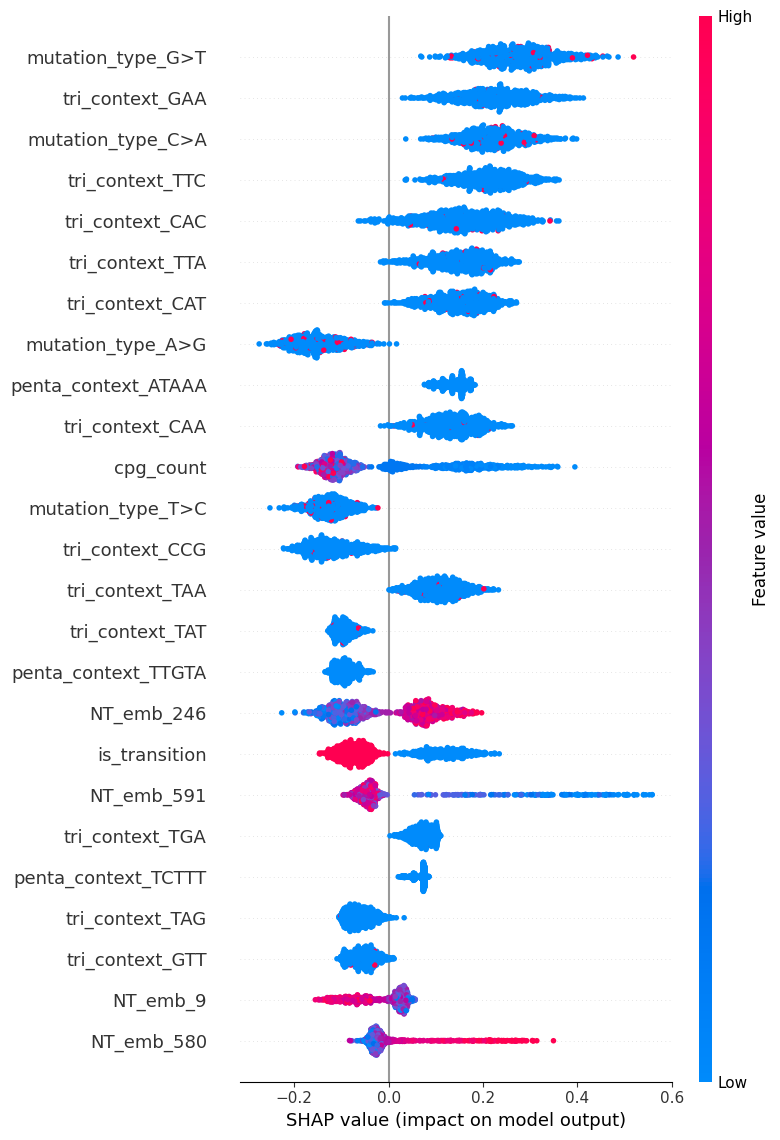

In [ ]:
import shap
import pandas as pd
import numpy as np


nt_feature_names = [f"NT_emb_{i}" for i in range(X_train_nt.shape[1])]

bio_feature_names = (
    num_features
    + list(
        preprocess_bio
        .named_transformers_["cat"]
        .get_feature_names_out(cat_features)
    )
)

hybrid_feature_names = nt_feature_names + bio_feature_names


X_sample = X_test_hybrid[:1000].toarray()

explainer = shap.TreeExplainer(hybrid_xgb)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=hybrid_feature_names,
    max_display=25
)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

nt_feature_names = [f"NT_emb_{i}" for i in range(X_train_nt.shape[1])]

bio_feature_names = (
    num_features
    + list(
        preprocess_bio
        .named_transformers_["cat"]
        .get_feature_names_out(cat_features)
    )
)

all_hybrid_feature_names = nt_feature_names + bio_feature_names

print("Features:", len(all_hybrid_feature_names))
print("Importances:", len(hybrid_xgb.feature_importances_))

Features: 9853
Importances: 9853


In [ ]:
importance_df = pd.DataFrame({
    "feature": all_hybrid_feature_names,
    "importance": hybrid_xgb.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
591,NT_emb_591,0.012121
246,NT_emb_246,0.010993
703,NT_emb_703,0.006594
374,NT_emb_374,0.005935
1285,cpg_count,0.004681
580,NT_emb_580,0.004073
428,NT_emb_428,0.003343
1289,is_transversion,0.003288
1288,is_transition,0.002935
960,NT_emb_960,0.002762


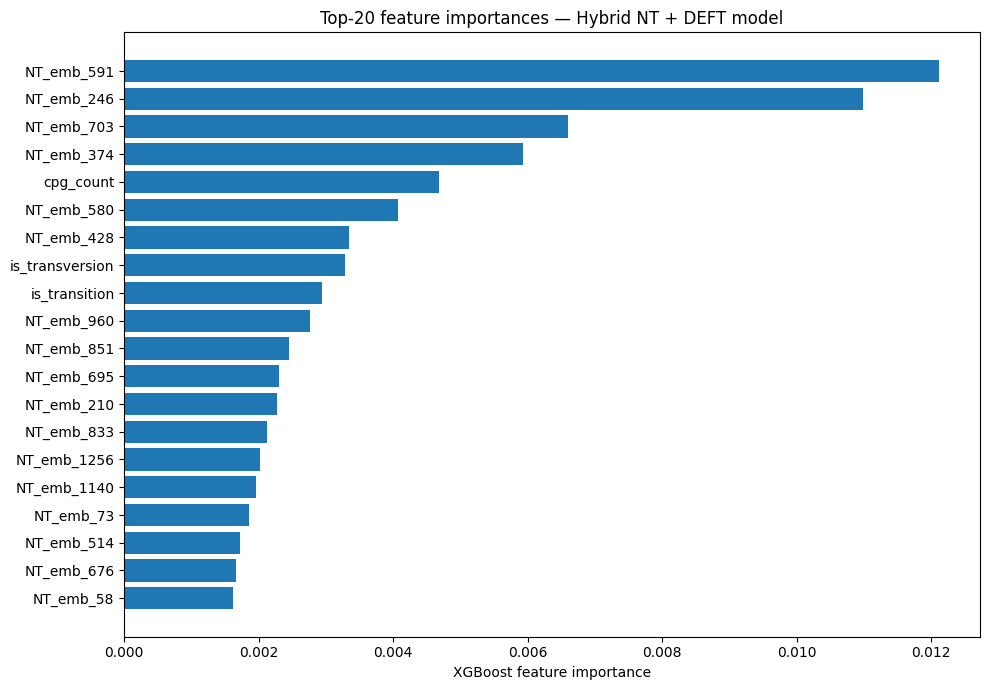

In [ ]:
top20 = importance_df.head(20).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(top20["feature"], top20["importance"])
plt.xlabel("XGBoost feature importance")
plt.title("Top-20 feature importances — Hybrid NT + DEFT model")
plt.tight_layout()
plt.show()

In [ ]:
bio_importance_df = importance_df[
    ~importance_df["feature"].str.startswith("NT_emb_")
].copy()

bio_importance_df.head(20)

,feature,importance
1285,cpg_count,0.004681
1289,is_transversion,0.003288
1288,is_transition,0.002935
1298,mutation_type_C>A,0.001468
1299,mutation_type_C>G,0.001439
1303,mutation_type_G>T,0.001436
1305,mutation_type_T>C,0.001359
1358,tri_context_TAT,0.001228
1296,mutation_type_A>G,0.001225
1287,core41_cpg,0.001212


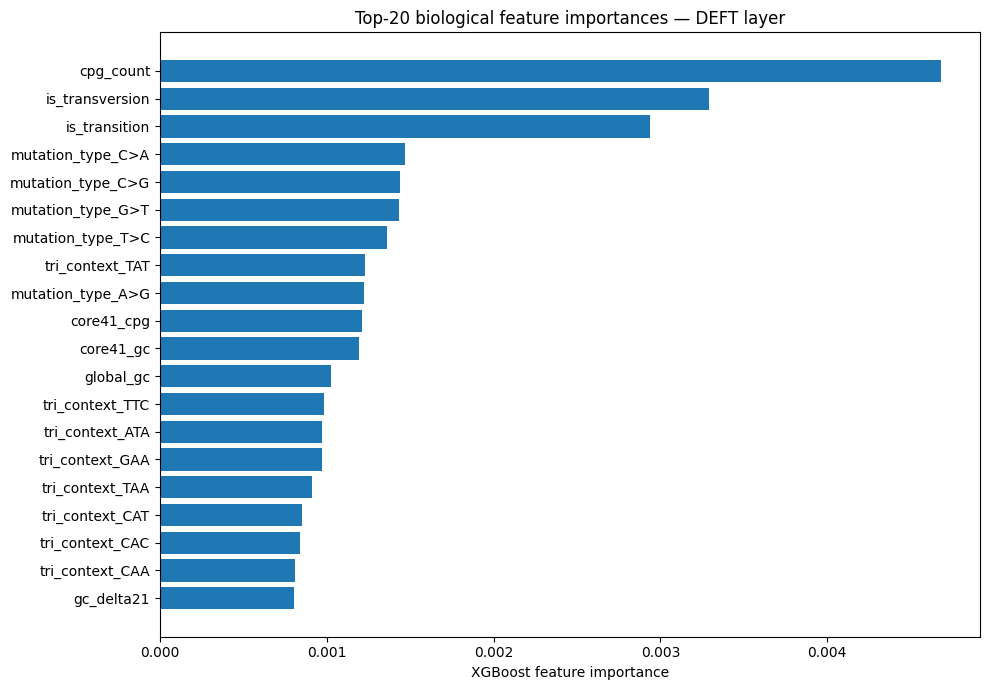

In [ ]:
top20_bio = bio_importance_df.head(20).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(top20_bio["feature"], top20_bio["importance"])
plt.xlabel("XGBoost feature importance")
plt.title("Top-20 biological feature importances — DEFT layer")
plt.tight_layout()
plt.show()

In [ ]:
!apt-get -qq install graphviz
!pip -q install graphviz

In [ ]:
from graphviz import Digraph

def build_bio_tree_graph(node):
    dot = Digraph(comment="Biological Recursive DEFT")
    dot.attr(rankdir="TB")
    dot.attr("node", shape="box", style="rounded,filled", fontname="Helvetica")

    counter = {"i": 0}

    def add_node(n):
        node_id = str(counter["i"])
        counter["i"] += 1

        if n.feature is None:
            label = (
                f"Predict: {'Somatic' if n.prediction == 1 else 'Germline'}\n"
                f"P(somatic) = {n.prob_somatic:.2f}\n"
                f"n = {n.n_samples}"
            )

            fill = "#FCE5CD" if n.prediction == 1 else "#D9EAD3"

            dot.node(node_id, label, fillcolor=fill)
            return node_id

        label = (
            f"{n.feature} {n.split_type} {n.threshold}\n"
            f"gain = {n.gain:.4f}\n"
            f"n = {n.n_samples}"
        )

        dot.node(node_id, label, fillcolor="#D9EAF7")

        left_id = add_node(n.left)
        right_id = add_node(n.right)

        dot.edge(node_id, left_id, label="Yes")
        dot.edge(node_id, right_id, label="No")

        return node_id

    add_node(node)
    return dot

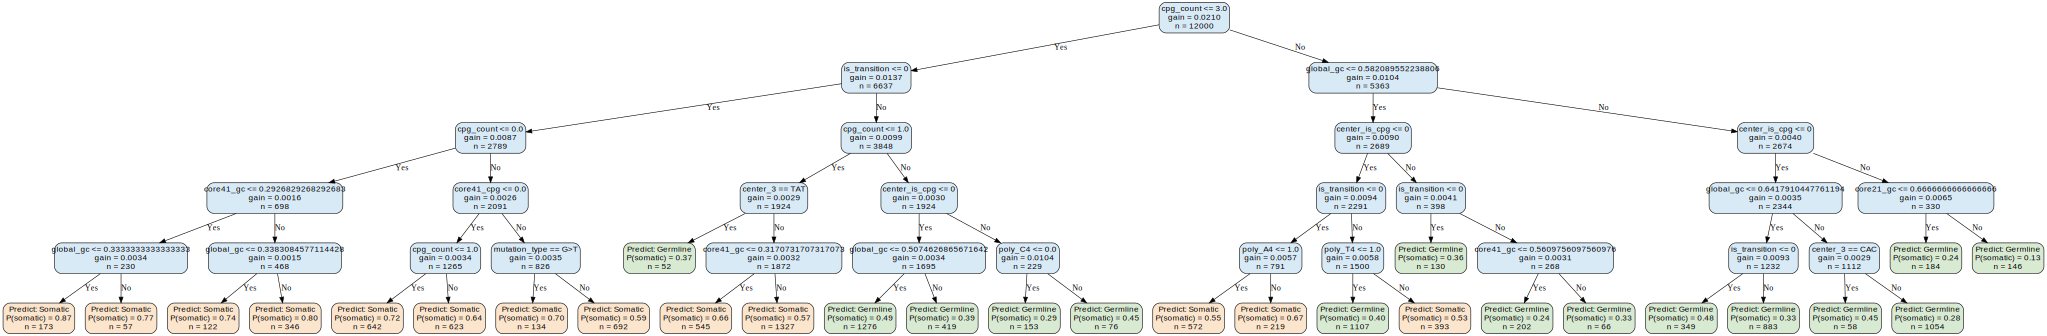

In [ ]:
dot = build_bio_tree_graph(bio_deft_tree)

dot.render(
    "/content/drive/MyDrive/dna_mutation_project/bio_deft_tree",
    format="png",
    cleanup=True
)

dot

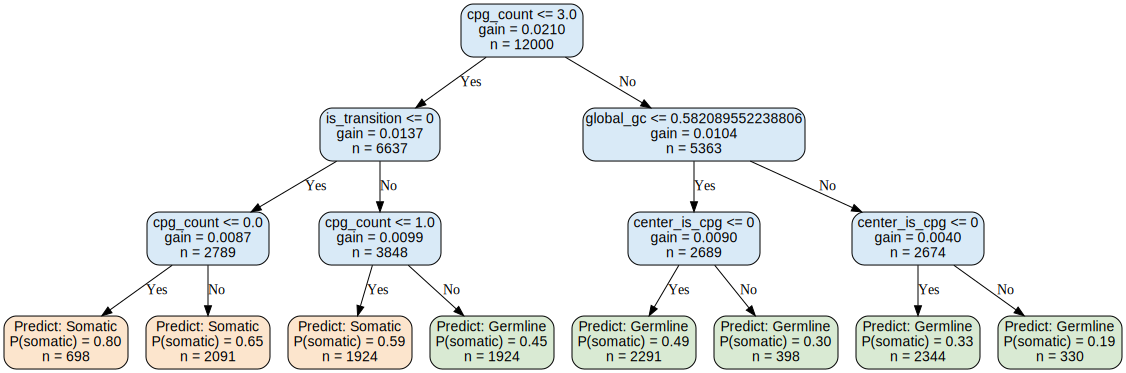

In [ ]:
bio_deft_tree_small = build_bio_deft(
    train_bio.reset_index(drop=True),
    y_train_arr,
    max_depth=3,
    min_samples=300,
    min_gain=0.001
)

dot = build_bio_tree_graph(bio_deft_tree_small)

dot.render(
    "/content/drive/MyDrive/dna_mutation_project/bio_deft_tree_small",
    format="png",
    cleanup=True
)

dot

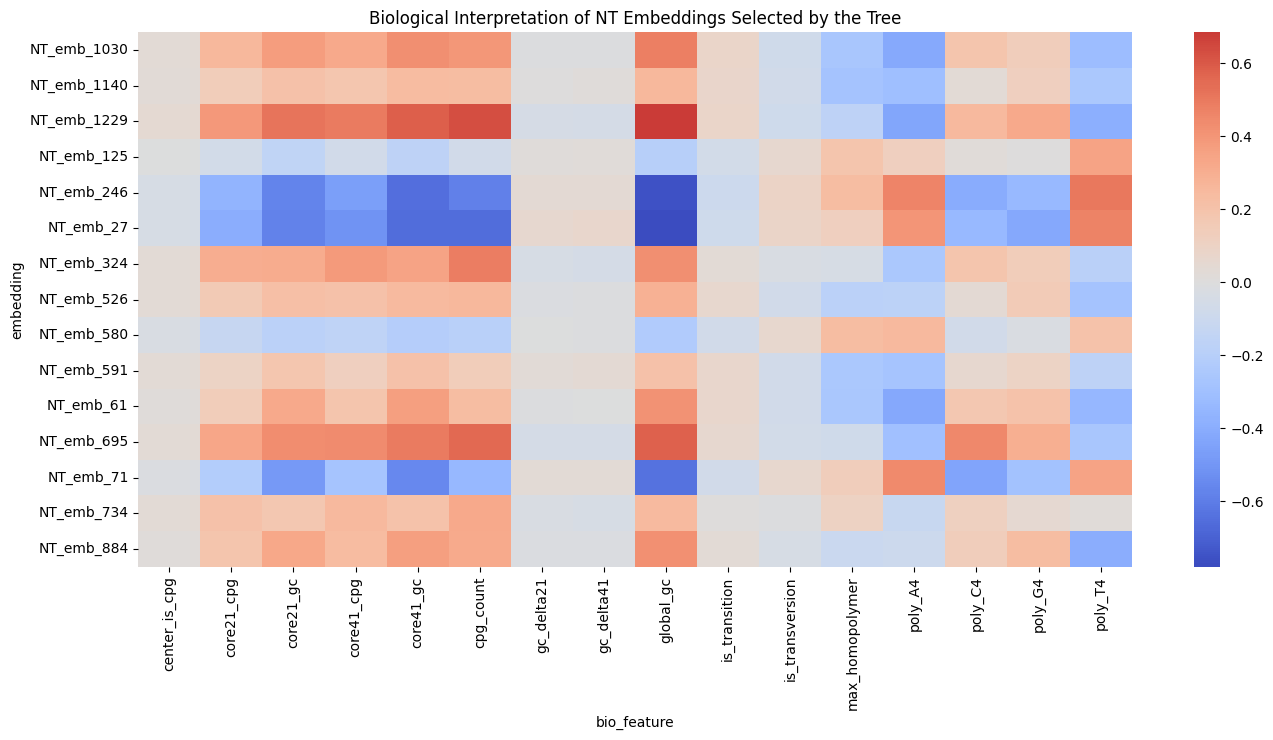

In [36]:
import seaborn as sns

if len(used_embeddings) > 0:
    heat_df = embedding_interpretation_df.pivot(
        index="embedding",
        columns="bio_feature",
        values="corr"
    )

    plt.figure(figsize=(14, max(5, len(used_embeddings) * 0.5)))
    sns.heatmap(
        heat_df,
        cmap="coolwarm",
        center=0,
        annot=False
    )
    plt.title("Biological Interpretation of NT Embeddings Selected by the Tree")
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/selected_embedding_interpretation_heatmap.png", dpi=300)
    plt.show()
else:
    print("No NT embeddings were selected by the tree.")